In [42]:
import pandas as pd
import numpy as np

In [43]:
df=pd.read_csv('Construction_Project_Analytics.csv')
df.head()

,Project_ID,Project_Name,Location,Project_Type,Area_sqft,Estimated_Budget_INR,Actual_Cost_INR,Material_Cost_INR,Labour_Cost_INR,Equipment_Cost_INR,...,Actual_Duration_Days,Delay_Days,Contractor,Project_Status,Start_Date,Expected_End_Date,Actual_End_Date,Budget_Variance_INR,Budget_Overrun_Pct,Cost_Per_Sqft_INR
0,P0001,Shree Heights,Pune,Residential,9324,24482000,22391000,7879000,4812000,1758000,...,331,5,Sunrise Constructions,Ongoing,2025-01-31,2025-12-23,2025-12-28,-2091000,-8.54,2401.44
1,P0002,Galaxy Plaza,Surat,Industrial,81323,167065000,189691000,73217000,53924000,26056000,...,738,0,Sunrise Constructions,Completed,2025-12-30,2028-01-07,2028-01-07,22626000,13.54,2332.56
2,P0003,Silver Plaza,Ahmedabad,Industrial,14111,28387000,29747000,9863000,8583000,3231000,...,385,120,Urban Infra,Ongoing,2024-05-10,2025-01-30,2025-05-30,1360000,4.79,2108.07
3,P0004,Silver Complex,Ahmedabad,Infrastructure,21389,57478000,57112000,23537000,10285000,7010000,...,220,0,Apex Developers,Ongoing,2025-07-18,2026-02-23,2026-02-23,-366000,-0.64,2670.16
4,P0005,Skyline Mall,Gandhinagar,Commercial,127177,402302000,329888000,150622000,82900000,36570000,...,390,30,GreenStone Projects,Completed,2025-02-04,2026-01-30,2026-03-01,-72414000,-18.00,2593.93


In [44]:
print('Shape of DataFrame')
print(df.shape)

Shape of DataFrame
(1000, 22)


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Project_ID              1000 non-null   object 
 1   Project_Name            1000 non-null   object 
 2   Location                1000 non-null   object 
 3   Project_Type            1000 non-null   object 
 4   Area_sqft               1000 non-null   int64  
 5   Estimated_Budget_INR    1000 non-null   int64  
 6   Actual_Cost_INR         1000 non-null   int64  
 7   Material_Cost_INR       1000 non-null   int64  
 8   Labour_Cost_INR         1000 non-null   int64  
 9   Equipment_Cost_INR      1000 non-null   int64  
 10  Other_Cost_INR          1000 non-null   int64  
 11  Expected_Duration_Days  1000 non-null   int64  
 12  Actual_Duration_Days    1000 non-null   int64  
 13  Delay_Days              1000 non-null   int64  
 14  Contractor              1000 non-null   o

In [46]:
df.describe()

,Area_sqft,Estimated_Budget_INR,Actual_Cost_INR,Material_Cost_INR,Labour_Cost_INR,Equipment_Cost_INR,Other_Cost_INR,Expected_Duration_Days,Actual_Duration_Days,Delay_Days,Budget_Variance_INR,Budget_Overrun_Pct,Cost_Per_Sqft_INR
count,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,78738.795000,2.042985e+08,2.080438e+08,8.282252e+07,4.996940e+07,2.317345e+07,5.207840e+07,524.734000,570.269000,45.535000,3.745226e+06,2.045150,2644.442530
std,41926.047455,1.188784e+08,1.235340e+08,5.053216e+07,3.072144e+07,1.476880e+07,3.446759e+07,224.000338,229.586905,45.081738,2.686369e+07,11.456528,605.997694
min,5126.000000,1.031900e+07,1.050300e+07,3.415000e+06,2.280000e+06,1.283000e+06,2.423000e+06,120.000000,127.000000,0.000000,-9.622800e+07,-18.000000,1404.030000
25%,42142.750000,1.046480e+08,1.051065e+08,4.104825e+07,2.507450e+07,1.125100e+07,2.486450e+07,336.750000,378.750000,5.000000,-1.018300e+07,-6.877500,2169.462500
50%,79156.500000,1.964705e+08,1.928720e+08,7.581900e+07,4.639300e+07,2.118800e+07,4.590250e+07,532.000000,574.500000,30.000000,1.772500e+06,1.585000,2625.510000
75%,115650.000000,2.853738e+08,2.912875e+08,1.152582e+08,7.080525e+07,3.319500e+07,7.140750e+07,714.500000,764.000000,89.250000,1.626975e+07,10.477500,3075.955000
max,149991.000000,5.346010e+08,5.697390e+08,2.627160e+08,1.627920e+08,8.157500e+07,1.808910e+08,899.000000,1025.000000,150.000000,1.271010e+08,35.000000,4442.810000


In [47]:
total_projects = len(df['Project_ID'])
total_budget = df['Estimated_Budget_INR'].sum()
average_budget = df['Estimated_Budget_INR'].mean()

print('Total Projects:', total_projects)
print('Total Estimated Budget: ₹', round(total_budget / 1e7, 2), 'Crore')
print('Average Estimated Budget: ₹', round(average_budget / 1e7, 2), 'Crore')

Total Projects: 1000
Total Estimated Budget: ₹ 20429.85 Crore
Average Estimated Budget: ₹ 20.43 Crore


In [48]:
total_cost=df['Actual_Cost_INR'].sum()
print('Total Actucal Cost: ₹',round(total_cost/1e7,2),'Crore')

budget_variance = (df['Actual_Cost_INR'] - df['Estimated_Budget_INR']).sum()
print('Budget Variance: ₹',round(budget_variance / 1e7, 2),'Crore')
# Here we can say that Actual Cost is more than Estimated Cost 

budget_overrun=((df['Actual_Cost_INR'].sum()-df['Estimated_Budget_INR'].sum()) / df['Estimated_Budget_INR'].sum())*100
print('Overall Budget Overrun Percentage:',round(budget_overrun,2),'%')
# Buget is Over Run by 1.83%

df['Budget_Variance_INR'] = (
    df['Actual_Cost_INR'] - df['Estimated_Budget_INR']
)

df['Budget_Overrun_Pct'] = (
    df['Budget_Variance_INR'] /
    df['Estimated_Budget_INR']
) * 100

Top_Overrun=df.sort_values('Budget_Overrun_Pct',ascending=False).head(10)

Top_Overrun[['Project_ID','Project_Name','Estimated_Budget_INR','Actual_Cost_INR','Budget_Overrun_Pct']]


print('Total Project with Under Budget and Over Budget')

under_budget=df.loc[df['Actual_Cost_INR']<df['Estimated_Budget_INR']]
over_budget=df.loc[df['Actual_Cost_INR']>df['Estimated_Budget_INR']]

print('Total Under Budget Project:',len(under_budget))
print('Total Over Budget Project:',len(over_budget))

project_type_analysis=df.groupby('Project_Type')['Budget_Overrun_Pct'].mean()
print(project_type_analysis)

Total Actucal Cost: ₹ 20804.38 Crore
Budget Variance: ₹ 374.52 Crore
Overall Budget Overrun Percentage: 1.83 %
Total Project with Under Budget and Over Budget
Total Under Budget Project: 456
Total Over Budget Project: 544
Project_Type
Commercial        1.795265
Industrial        1.960853
Infrastructure    1.678956
Residential       2.712300
Name: Budget_Overrun_Pct, dtype: float64


### Location Analysis

In [49]:
# City-Wise Cost,Overrun,Delays 

cost_city_wise=df.groupby('Location')['Actual_Cost_INR'].sum()/1e7
print('City Wise Cost Actual Cost (Crore)')
print(cost_city_wise.round(2))

City Wise Cost Actual Cost (Crore)
Location
Ahmedabad      9025.78
Gandhinagar    2043.06
Mumbai         1800.96
Pune           1781.99
Rajkot         2203.37
Surat          2181.72
Vadodara       1767.49
Name: Actual_Cost_INR, dtype: float64


### Component Cost

In [54]:
cost_component=df[['Material_Cost_INR','Labour_Cost_INR','Equipment_Cost_INR','Other_Cost_INR']].sum()
print('Cost Component Analysis (Crore)')
print((cost_component/1e7).round(2))

print()

cost_percentage=(cost_component/df['Actual_Cost_INR'].sum())*100
print('Cost Component Percentage (%)')
print(cost_percentage.round(2))

Cost Component Analysis (Crore)
Material_Cost_INR     8282.25
Labour_Cost_INR       4996.94
Equipment_Cost_INR    2317.34
Other_Cost_INR        5207.84
dtype: float64

Cost Component Percentage (%)
Material_Cost_INR     39.81
Labour_Cost_INR       24.02
Equipment_Cost_INR    11.14
Other_Cost_INR        25.03
dtype: float64


### Dealayed Projects 

In [61]:
delayed_projects=df.loc[df['Delay_Days']>0]
print('Total Delayed Projects:',len(delayed_projects))
print('Total On-Time Projects:',len(df.loc[df['Delay_Days']==0]))

# Average Delay
avg_delay=df['Delay_Days'].mean()
print('Average Delayed Days:',round(avg_delay,2),'days')

# Maximum Delay
max_delay=df['Delay_Days'].max()
print('Maximum Delayed Days:',max_delay,'days')

# Highest Delay Project
highest_delay=df.sort_values('Delay_Days',ascending=False).head(10)
highest_delay[['Project_ID','Project_Name','Location','Project_Type','Delay_Days']]


Total Delayed Projects: 795
Total On-Time Projects: 205
Average Delayed Days: 45.54 days
Maximum Delayed Days: 150 days


,Project_ID,Project_Name,Location,Project_Type,Delay_Days
219,P0220,Sunrise Enclave,Ahmedabad,Industrial,150
348,P0349,Green Valley Industrial Park,Mumbai,Industrial,150
692,P0693,Crystal Enclave,Surat,Industrial,149
359,P0360,Silver Industrial Park,Ahmedabad,Industrial,149
445,P0446,Sunrise Heights,Ahmedabad,Residential,149
282,P0283,Metro Mall,Surat,Commercial,149
160,P0161,Royal Mall,Ahmedabad,Commercial,148
639,P0640,Metro Business Park,Rajkot,Commercial,147
906,P0907,Silver Residency,Ahmedabad,Commercial,147
915,P0916,Sunrise Business Park,Ahmedabad,Industrial,146


### Contractor Analysis

In [73]:
contractor_analysis=df.groupby('Contractor').agg(Total_Projects=('Project_ID','count'),
                                                Average_Overrun=('Budget_Overrun_Pct','mean'),
                                                Average_Delay=('Delay_Days','mean'),
                                                Total_Actual_Cost=('Actual_Cost_INR','sum'))
contractor_analysis['Total_Actual_Cost_Crore']=(contractor_analysis['Total_Actual_Cost']/1e7).round(2)
contractor_analysis.drop(columns='Total_Actual_Cost')
contractor_analysis

# Highest Overrun Contractor
highest_overrun_Contractor=contractor_analysis['Average_Overrun'].idxmax()
print('Highest Average Budget Overrun Contractor:',highest_overrun_Contractor)

highest_delay_Contractor=contractor_analysis['Average_Delay'].idxmax()
print('Highest Average Delay Contractor:',highest_delay_Contractor)

Highest Average Budget Overrun Contractor: MetroBuild
Highest Average Delay Contractor: Patel Construction


### Project Status Analysis

In [76]:
# Status Analysis based on category
status_analysis=df['Project_Status'].value_counts()
print('Project Status Analysis')
print(status_analysis)

print()

# Status Percentage based on Category
status_percentage=df['Project_Status'].value_counts(normalize=True)*100
print('Project Status Percentage')
print(status_percentage)

Project Status Analysis
Project_Status
Completed    504
Ongoing      319
Delayed      177
Name: count, dtype: int64

Project Status Percentage
Project_Status
Completed    50.4
Ongoing      31.9
Delayed      17.7
Name: proportion, dtype: float64


### Relationship Analysis

In [88]:
# Area per Sqft v/s Actual_Cost 
area_cost_correlation=df[['Area_sqft','Actual_Cost_INR']].corr()
area_cost_correlation

# Cost per Sqft v/s Area

area_cost_sqft=df[['Area_sqft','Cost_Per_Sqft_INR']].corr()
area_cost_sqft

# Duration v/s Actual Cost

Duration_Actual_Cost_Correlation=df[['Actual_Duration_Days','Actual_Cost_INR']].corr()
Duration_Actual_Cost_Correlation

# Budget_Overrun v/s Delay

Overrun_Delay_Correlation=df[['Delay_Days','Budget_Overrun_Pct']].corr()
Overrun_Delay_Correlation
# so we can not say that Delay happnes due to Budget Overrun Problem 

# cost_per_sqft by Project Type

cost_sqft_analysis=df.groupby('Project_Type').agg(
    Total_Projects=('Project_ID','count'),
    Average_Cost_Per_Sqft=('Cost_Per_Sqft_INR','mean')
)
print(cost_sqft_analysis.round(2))
# Commercial Projects have more Average Cost Per Sqft


                Total_Projects  Average_Cost_Per_Sqft
Project_Type                                         
Commercial                 231                3307.55
Industrial                 262                1962.75
Infrastructure             250                2898.16
Residential                257                2496.56


### Data Visulization

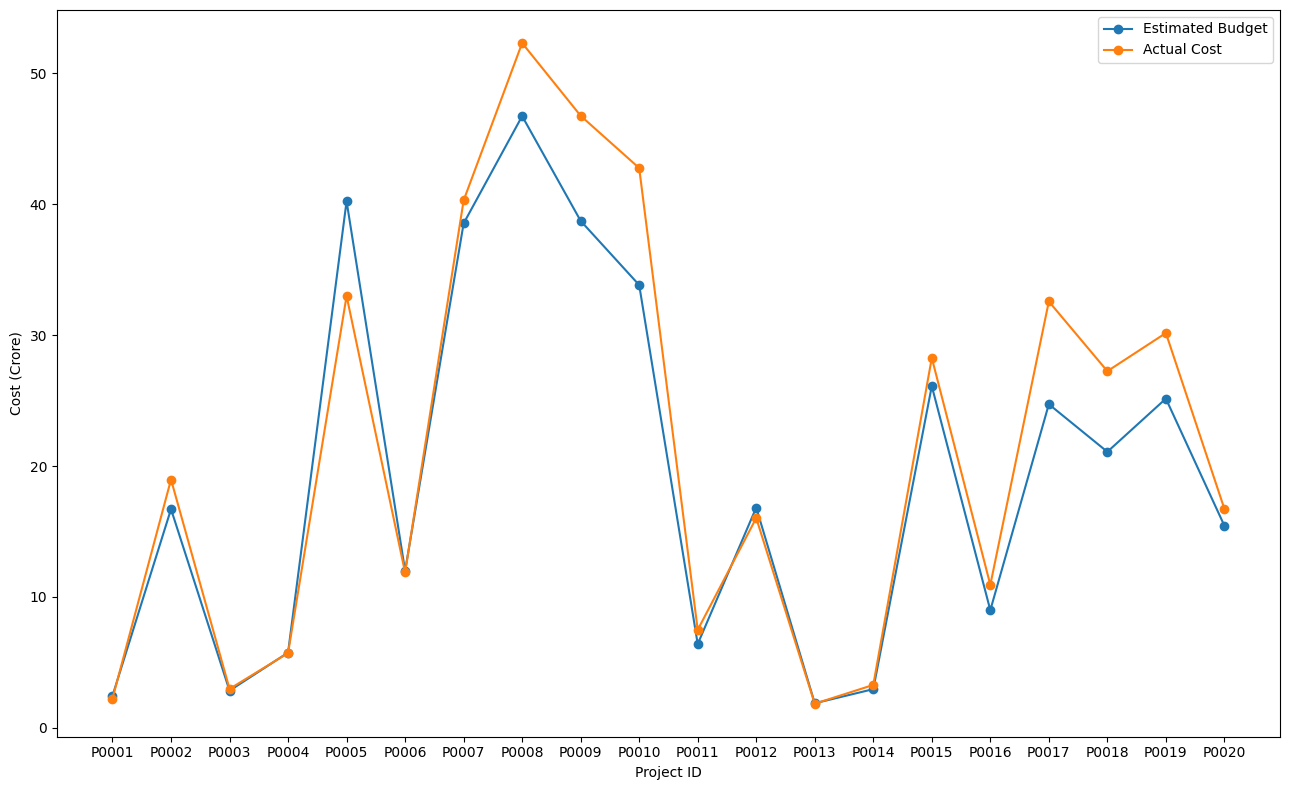

In [108]:
# Budget vs Actual Cost

# Here we can analyze that actual cost v/s estimated budget and we can conclude that which project has problem of overrun

import matplotlib.pyplot as plt
import plotly.express as px

sample=df.head(20)

plt.figure(figsize=(13,8))

plt.plot(sample['Project_ID'],sample['Estimated_Budget_INR']/1e7,marker='o',label='Estimated Budget')
plt.plot(sample['Project_ID'],sample['Actual_Cost_INR'] / 1e7, marker='o',label='Actual Cost')
plt.xlabel('Project ID')
plt.ylabel('Cost (Crore)')
plt.legend()
plt.tight_layout()
plt.show()

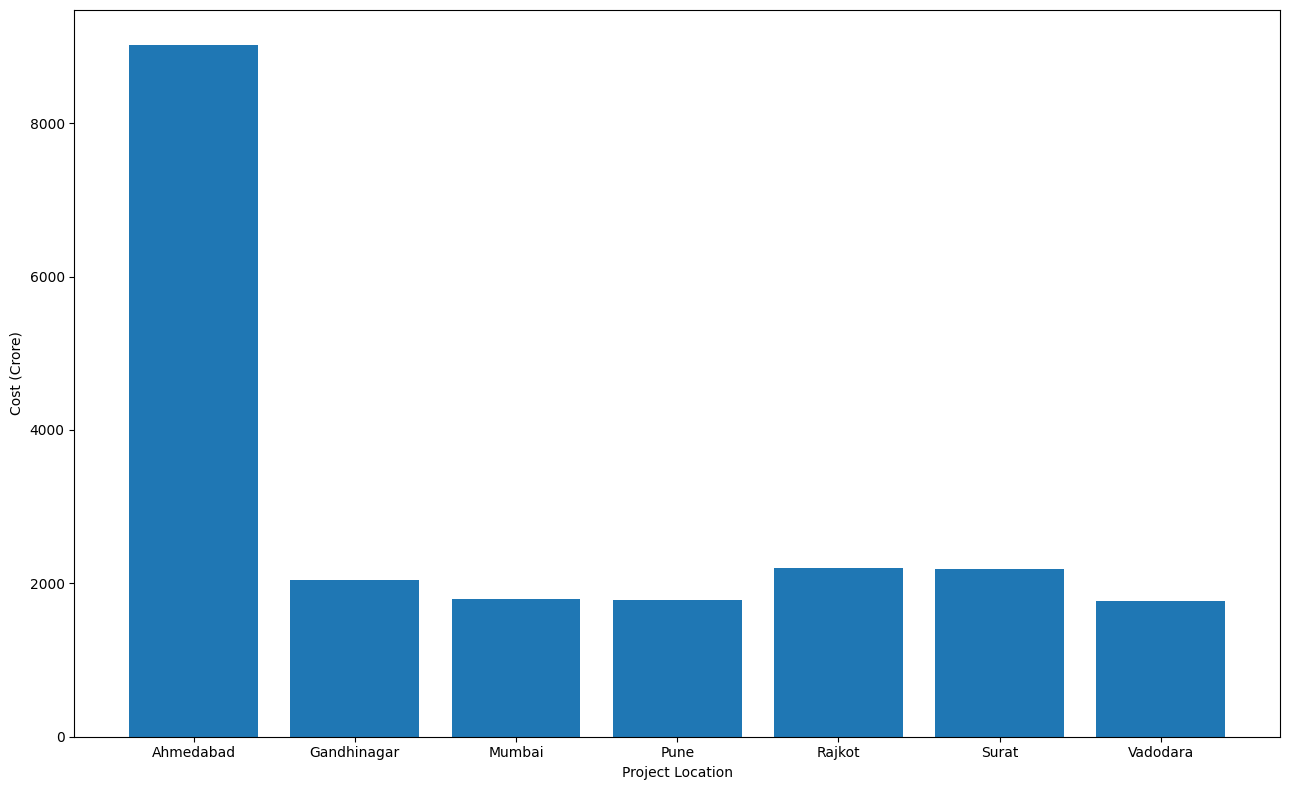

In [101]:
# Location Wise Cost
location_cost = (df.groupby('Location')['Actual_Cost_INR'].sum()/ 1e7)

plt.figure(figsize=(13,8))
plt.bar(location_cost.index,location_cost.values)
plt.xlabel('Project Location')
plt.ylabel('Cost (Crore)')
plt.tight_layout()
plt.show()

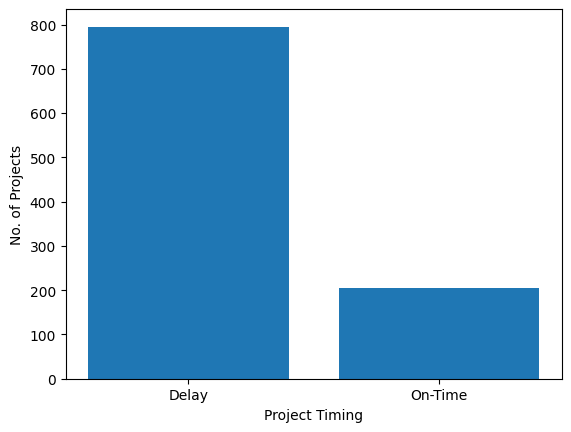

In [107]:
# Delay v/s On Time Project

project_timing=np.where(df['Delay_Days']>0,'Delay','On-Time')

timing_count = pd.Series(project_timing).value_counts()
plt.bar(timing_count.index,timing_count.values)
plt.xlabel('Project Timing')
plt.ylabel('No. of Projects')
plt.show()

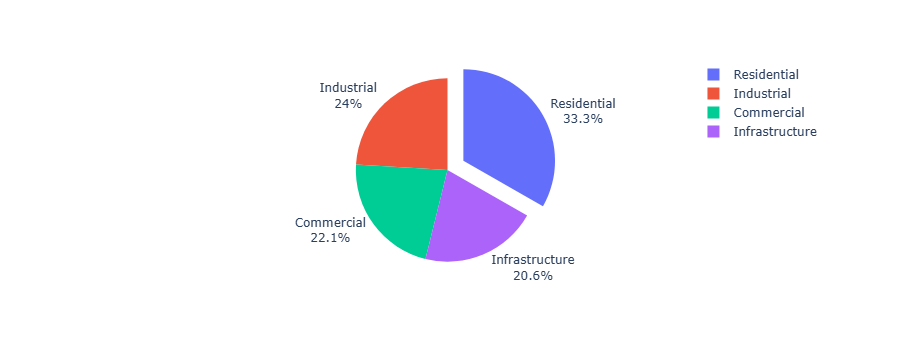

In [117]:
# Budget Overrun by project type

budget_overrun=df.groupby('Project_Type')['Budget_Overrun_Pct'].mean().round(2)

fig=px.pie(budget_overrun,names=budget_overrun.index,values=budget_overrun.values)
fig.update_traces(textinfo='percent+label',textposition='outside',pull=[0,0,0,0.2])
fig.show()